In [39]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from tqdm import tqdm
import random
from pyqlearning.q_learning import QLearning
import matplotlib.pyplot as plt
from cesnet_datazoo.config import DatasetConfig, ValidationApproach, AppSelection
from cesnet_datazoo.constants import APP_COLUMN
import numpy as np
import hashlib

np.random.seed(0xdeadd00d)

In [40]:
from cesnet_datazoo.datasets import CESNET_QUIC22
dataset = CESNET_QUIC22("~/datasets/CESNET-QUIC22/", size="XS")

In [41]:
dataset_config = DatasetConfig(
    dataset=dataset,
    apps_selection=AppSelection.TOPX_KNOWN,
    apps_selection_topx=10,
    val_approach=ValidationApproach.SPLIT_FROM_TRAIN,
    train_period_name='W-2022-44',
    test_period_name='W-2022-45',
    train_size=200000
)

In [42]:
dataset.set_dataset_config_and_initialize(dataset_config)

In [43]:
feature_names = dataset_config.get_feature_names(flatten_ppi=True)
train_df = dataset.get_train_df(flatten_ppi=True)
val_df = dataset.get_val_df(flatten_ppi=True)
test_df = dataset.get_test_df(flatten_ppi=True)
train_labels = train_df.pop(APP_COLUMN)
val_labels = val_df.pop(APP_COLUMN)
test_labels = test_df.pop(APP_COLUMN)

Loading data from dataloader


100%|██████████| 1042/1042 [00:10<00:00, 97.95it/s] 


Loading data from dataloader


100%|██████████| 138/138 [00:06<00:00, 21.54it/s]


Loading data from dataloader


100%|██████████| 250/250 [00:08<00:00, 30.72it/s]


In [44]:
# select small sample of train_df as start labeled set
labeled_indices, unlabeled_indices = train_test_split(train_df.index, train_size=10, stratify=train_labels)

In [45]:
labeled_df = train_df.loc[labeled_indices]
labeled_labels = train_labels.loc[labeled_indices]
unlabeled_df = train_df.loc[unlabeled_indices]
unlabeled_labels = train_labels.loc[unlabeled_indices]
print("Labeled data:", labeled_df.shape)
print("Unlabeled data:", unlabeled_df.shape)

Labeled data: (10, 101)
Unlabeled data: (199990, 101)


In [46]:
# Function to compute the hash for a given state
def hash_state(state):
    state_str = str(state).encode('utf-8')
    return int(hashlib.sha256(state_str).hexdigest(), 16) % 1024

# Function to get the state for each sample in the dataset
def get_state(df, log_bins):
    states = []
    for _, row in df.iterrows():
        state = []
        for feature, edges in log_bins.items():
            if pd.isna(row[feature]):
                bin_index = 0  # Assign NaN values to bin 0
            else:
                bin_index = np.digitize(row[feature], bins=edges, right=False) - 1
                bin_index = max(0, min(bin_index, len(edges) - 2))
            state.append(bin_index)
        hashed_state = hash_state(tuple(state))
        states.append(hashed_state)
    
    return pd.Series(states, index=df.index)

In [47]:
# Example of features and their logarithmic bins
features = ["BYTES", "BYTES_REV", "PACKETS", "PACKETS_REV", "DURATION", "PPI_LEN", "PPI_DURATION"]

log_bins = {}
for feature in features:
    min_val = unlabeled_df[feature].min()
    max_val = unlabeled_df[feature].max()
    
    if min_val <= 0:
        min_val = 1e-6
    
    num_bins = 5
    log_min = np.log10(min_val)
    log_max = np.log10(max_val)
    log_edges = np.linspace(log_min, log_max, num_bins + 1)
    
    bin_edges = np.power(10, log_edges)
    log_bins[feature] = bin_edges

# Calculate the state for the entire dataset
unlabeled_df["hashed_state"] = get_state(unlabeled_df, log_bins)
labeled_df["hashed_state"] = get_state(labeled_df, log_bins)

In [48]:
class QLearningAgent:
    def __init__(self, n_actions, learning_rate=0.1, discount_factor=0.95, exploration_rate=0.9, exploration_decay=0.99):
        self.q_table = {}  # State-action Q-table
        self.n_actions = n_actions
        self.learning_rate = learning_rate
        self.discount_factor = discount_factor
        self.exploration_rate = exploration_rate
        self.exploration_decay = exploration_decay

    def choose_action(self, state, uncertainties, available_actions):
        if np.random.rand() < self.exploration_rate:  # Exploration
            return np.random.choice(available_actions)
        else:  # Exploitation
            self.q_table.setdefault(state, np.zeros(self.n_actions))
            best_action = max(available_actions, key=lambda a: (self.q_table[state][a%2048], uncertainties[a%2048]))
            return best_action

    def update_q_table(self, state, action, reward, next_state):
        self.q_table.setdefault(state, np.zeros(self.n_actions))
        self.q_table.setdefault(next_state, np.zeros(self.n_actions))

        self.q_table[state][action] = (1 - self.learning_rate) * self.q_table[state][action] + self.learning_rate * (reward + self.discount_factor * np.max(self.q_table[next_state]))

        print(action)

        self.exploration_rate *= self.exploration_decay

In [49]:
def random_sampling(X_pool: pd.DataFrame, y_pool: pd.DataFrame, n_samples: int):
    indices = np.random.choice(len(X_pool), n_samples, replace=False)
    return X_pool.iloc[indices], y_pool.iloc[indices], indices

def uncertainty_sampling(clf: RandomForestClassifier, X_pool: pd.DataFrame, y_pool: pd.DataFrame, n_samples: int):
    probs = clf.predict_proba(X_pool.drop("hashed_state", inplace=False, axis=1))
    uncertainties = 1 - np.max(probs, axis=1)
    indices = np.argsort(uncertainties)[-n_samples:]
    return X_pool.iloc[indices], y_pool.iloc[indices], indices

In [56]:
n_iterations = 100
sample_size = 1

results = {
    "random": [],
    "uncertainty": [],
    "q_learning": []
}

# Create fresh copies of the data for each strategy
labeled_df_random = labeled_df.copy()
labeled_labels_random = labeled_labels.copy()
labeled_df_uncertainty = labeled_df.copy()
labeled_labels_uncertainty = labeled_labels.copy()
labeled_df_qlearning = labeled_df.copy()
labeled_labels_qlearning = labeled_labels.copy()

unlabeled_df_random = unlabeled_df.copy()
unlabeled_labels_random = unlabeled_labels.copy()
unlabeled_df_uncertainty = unlabeled_df.copy()
unlabeled_labels_uncertainty = unlabeled_labels.copy()
unlabeled_df_qlearning = unlabeled_df.copy()
unlabeled_labels_qlearning = unlabeled_labels.copy()

clf_random = RandomForestClassifier(n_estimators=10, max_depth=5)
clf_uncertainty = RandomForestClassifier(n_estimators=10, max_depth=5)
clf_qlearning = RandomForestClassifier(n_estimators=10, max_depth=5)

agent = QLearningAgent(n_actions=2048)

for _ in tqdm(range(n_iterations)):
    # Random Sampling
    clf_random.fit(labeled_df_random.drop("hashed_state", inplace=False, axis=1), labeled_labels_random)
    score = f1_score(val_labels, clf_random.predict(val_df), average='macro')
    results["random"].append(score)

    X_sample, y_sample, indices = random_sampling(unlabeled_df_random, unlabeled_labels_random, sample_size)
    labeled_df_random = pd.concat([labeled_df_random, X_sample])
    labeled_labels_random = pd.concat([labeled_labels_random, y_sample])
    unlabeled_df_random = unlabeled_df_random.drop(indices)
    unlabeled_labels_random = unlabeled_labels_random.drop(indices)

    labeled_df_random.reset_index(inplace=True, drop=True)
    unlabeled_df_random.reset_index(inplace=True, drop=True)
    labeled_labels_random.reset_index(inplace=True, drop=True)
    unlabeled_labels_random.reset_index(inplace=True, drop=True)

    # Uncertainty Sampling
    clf_uncertainty.fit(labeled_df_uncertainty.drop("hashed_state", inplace=False, axis=1), labeled_labels_uncertainty)
    score = f1_score(val_labels, clf_uncertainty.predict(val_df), average='macro')
    results["uncertainty"].append(score)

    X_sample, y_sample, indices = uncertainty_sampling(clf_uncertainty, unlabeled_df_uncertainty, unlabeled_labels_uncertainty, sample_size)
    labeled_df_uncertainty = pd.concat([labeled_df_uncertainty, X_sample])
    labeled_labels_uncertainty = pd.concat([labeled_labels_uncertainty, y_sample])
    unlabeled_df_uncertainty = unlabeled_df_uncertainty.drop(indices)
    unlabeled_labels_uncertainty = unlabeled_labels_uncertainty.drop(indices)

    labeled_df_uncertainty.reset_index(inplace=True, drop=True)
    unlabeled_df_uncertainty.reset_index(inplace=True, drop=True)
    labeled_labels_uncertainty.reset_index(inplace=True, drop=True)
    unlabeled_labels_uncertainty.reset_index(inplace=True, drop=True)

    # Q-learning Sampling
    clf_qlearning.fit(labeled_df_qlearning.drop("hashed_state", inplace=False, axis=1), labeled_labels_qlearning)
    probs = clf_qlearning.predict_proba(unlabeled_df_qlearning.drop("hashed_state", inplace=False, axis=1))
    uncertainties = 1 - np.max(probs, axis=1)
    current_score = f1_score(val_labels, clf_qlearning.predict(val_df), average='macro')
    results["q_learning"].append(current_score)

    # Use the hashed_state column as the state
    state = unlabeled_df_qlearning["hashed_state"].iloc[0]  # Use hashed_state as the state

    # Choose a subset of actions to explore
    available_actions = np.random.choice(unlabeled_df_qlearning.index, size=min(10, 2048), replace=False)

    # Choose action
    action = agent.choose_action(state, uncertainties, available_actions)
    action = int(unlabeled_df_qlearning.iloc[action]["hashed_state"])

    # Perform the action (select a sample for labeling)
    X_sample = unlabeled_df_qlearning.iloc[[action]].drop("hashed_state", axis=1)
    y_sample = unlabeled_labels_qlearning.iloc[[action]]

    labeled_df_qlearning = pd.concat([labeled_df_qlearning, X_sample])
    labeled_labels_qlearning = pd.concat([labeled_labels_qlearning, y_sample])
    unlabeled_df_qlearning = unlabeled_df_qlearning.drop(action)
    unlabeled_labels_qlearning = unlabeled_labels_qlearning.drop(action)

    labeled_df_qlearning.reset_index(inplace=True, drop=True)
    unlabeled_df_qlearning.reset_index(inplace=True, drop=True)
    labeled_labels_qlearning.reset_index(inplace=True, drop=True)
    unlabeled_labels_qlearning.reset_index(inplace=True, drop=True)

    # Re-train and calculate the new score
    clf_qlearning.fit(labeled_df_qlearning.drop("hashed_state", inplace=False, axis=1), labeled_labels_qlearning)
    new_score = f1_score(val_labels, clf_qlearning.predict(val_df), average='macro')

    # Calculate reward as the improvement in score
    reward = new_score - current_score
    next_state = unlabeled_df_qlearning["hashed_state"].iloc[0]  # Assuming the state is consistent per sample
    agent.update_q_table(state, action, reward, next_state)

plt.plot(results["random"], label="Random Sampling")
plt.plot(results["uncertainty"], label="Uncertainty Sampling")
plt.plot(results["q_learning"], label="Q-learning Sampling")
plt.xlabel("Iteration")
plt.ylabel("F1 macro score")
plt.legend()
plt.show()

# Test report 
print("-----------------")
print("Random Sampling")
print(f1_score(test_labels, clf_random.predict(test_df), average='macro'))
print("-----------------")
print("Uncertainty Sampling")
print(f1_score(test_labels, clf_uncertainty.predict(test_df), average='macro'))
print("-----------------")
print("Q-learning Sampling")
print(f1_score(test_labels, clf_qlearning.predict(test_df), average='macro'))
print("-----------------")

0:0.7
1:0.4
2:0.6
3:0.5
4:0.6
5:0.6
6:0.7
7:0.5
8:0.6
9:0.7
10:0.7
11:0.6
12:0.6
13:0.7
14:0.5
15:0.6
16:0.5
17:0.30000000000000004
18:0.6
19:0.5
20:0.7
21:0.5
22:0.6
23:0.5
24:0.6
25:0.6
26:0.6
27:0.6
28:0.6
29:0.6
30:0.5
31:0.7
32:0.30000000000000004
33:0.6
34:0.7
35:0.6
36:0.7
37:0.5
38:0.5
39:0.6
40:0.7
41:0.7
42:0.6
43:0.4
44:0.6
45:0.6
46:0.4
47:0.7
48:0.5
49:0.19999999999999996
50:0.6
51:0.7
52:0.6
53:0.7
54:0.5
55:0.5
56:0.4
57:0.5
58:0.6
59:0.4
60:0.6
61:0.6
62:0.7
63:0.5
64:0.5
65:0.6
66:0.7
67:0.7
68:0.6
69:0.7
70:0.6
71:0.7
72:0.6
73:0.5
74:0.6
75:0.4
76:0.5
77:0.6
78:0.6
79:0.7
80:0.7
81:0.7
82:0.6
83:0.7
84:0.7
85:0.7
86:0.7
87:0.4
88:0.6
89:0.6
90:0.7
91:0.6
92:0.6
93:0.7
94:0.6
95:0.6
96:0.6
97:0.7
98:0.7
99:0.7
100:0.6
101:0.7
102:0.7
103:0.5
104:0.7
105:0.6
106:0.6
107:0.7
108:0.6
109:0.4
110:0.8
111:0.4
112:0.6
113:0.6
114:0.5
115:0.7
116:0.7
117:0.7
118:0.5
119:0.7
120:0.6
121:0.8
122:0.6
123:0.5
124:0.7
125:0.5
126:0.7
127:0.7
128:0.7
129:0.8
130:0.7
131:0.7
132:0.

958


  1%|          | 1/100 [00:03<06:07,  3.71s/it]


KeyboardInterrupt: 

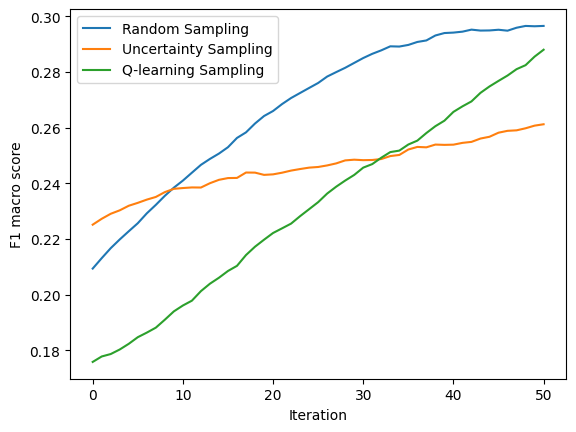

In [ ]:
window_size = 50

def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

random_smoothed = moving_average(results["random"], window_size)
uncertainty_smoothed = moving_average(results["uncertainty"], window_size)
q_learning_smoothed = moving_average(results["q_learning"], window_size)

x_axis = np.arange(len(random_smoothed))

# Plot the smoothed data
plt.plot(x_axis, random_smoothed, label="Random Sampling")
plt.plot(x_axis, uncertainty_smoothed, label="Uncertainty Sampling")
plt.plot(x_axis, q_learning_smoothed, label="Q-learning Sampling")
plt.xlabel("Iteration")
plt.ylabel("F1 macro score")
plt.legend()
plt.show()